In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

In [2]:
config = {
    "key": "comb_Am_rp",
    "ds": "x8x8",
    "data": {
        "path": "/mnt/data/sumiya/mocat-ml/data",
    },
    "lookback": 1,
    "horizon": 1,
    "gap": 1,
    "stride": 8,
}


In [3]:
path = f'{config['data']['path']}/TLE_density_all_{config['ds']}.mat'
mat = h5py.File(path, 'r')
mat

<HDF5 file "TLE_density_all_x8x8.mat" (mode r)>

In [4]:
for key in mat.keys():
    try:
        print(key, mat[key].shape, type(mat[key]))
    except:
        print(key, type(mat[key]))

#refs# <class 'h5py._hl.group.Group'>
#subsystem# <class 'h5py._hl.group.Group'>
Am_disc (100, 1) <class 'h5py._hl.dataset.Dataset'>
MCconfig <class 'h5py._hl.group.Group'>
comb_Am_inc (100, 2436, 180, 99) <class 'h5py._hl.dataset.Dataset'>
comb_Am_ra (100, 2436, 36, 99) <class 'h5py._hl.dataset.Dataset'>
comb_Am_rp (100, 2436, 36, 99) <class 'h5py._hl.dataset.Dataset'>
comb_inc_ra (100, 2436, 36, 180) <class 'h5py._hl.dataset.Dataset'>
comb_inc_rp (100, 2436, 36, 180) <class 'h5py._hl.dataset.Dataset'>
comb_ra_rp (100, 2436, 36, 36) <class 'h5py._hl.dataset.Dataset'>
inc_disc (181, 1) <class 'h5py._hl.dataset.Dataset'>
param <class 'h5py._hl.group.Group'>
paramSSEM <class 'h5py._hl.group.Group'>
ra_disc (37, 1) <class 'h5py._hl.dataset.Dataset'>
rp_disc (37, 1) <class 'h5py._hl.dataset.Dataset'>
time_density (1, 2436) <class 'h5py._hl.dataset.Dataset'>


(100, 2436, 36, 99)


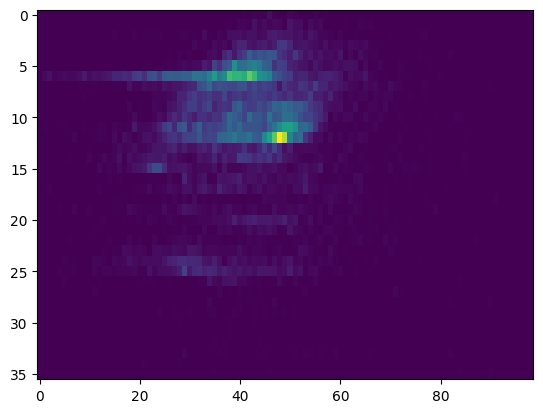

In [5]:
data = mat[config['key']]   
print(data.shape) 
# prints (100, 2436, 36, 99) -> 100 is the number of simulations, 2436 is the number of timesteps, 36 is the number of x coordinates, 99 is the number of y coordinates
# x and y coordinates are number of discrete bins in the spatial domain given by 'key' (in this case Am and rp)
plt.imshow(data[0][0], aspect = 'auto')

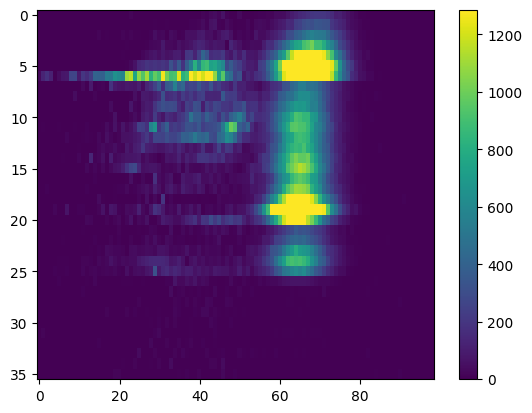

In [11]:
from matplotlib.animation import FuncAnimation
from matplotlib import rc
rc('animation', html='html5') 

data = mat[config['key']]
data, stride = data[0], 100
fig = plt.figure()
ax = fig.add_subplot(111)
im = ax.imshow(data[0,:,:], aspect='auto')
fig.colorbar(im, ax=ax)

def animate(i, im, fig):
    im.set_array(data[stride*i,:, :])  # Update data
    return im,

ani = FuncAnimation(fig, animate, frames=data.shape[0]//stride, fargs=(im, fig), blit=True)
ani